In [6]:
import seaborn as sns

sns.set_context('paper',font_scale=1.5)
sns.set_style('ticks')

# Formation energies

Formation energy plots are central in the analysis of point defects. The convention is to plot the formation energies as a function of the Fermi level, showing only the charge state with lowest formation energy. You can generate the plot automatically using the `DefectsAnalysis`. First we initialize the class following the previous examples: 

In [2]:
import pandas as pd
from defermi import DefectsAnalysis

bulk_volume = 800 # cubic Amstrong
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0.0)
da

,name,delta atoms,charge,multiplicity,corrections
0,Vac_O,{'O': -1},0,1,{}
1,Vac_O,{'O': -1},2,1,{}
2,Vac_Sr,{'Sr': -1},-2,1,{}
3,Vac_Sr,{'Sr': -1},0,1,{}


For the calculation of formation energies we need to define chemical potentials for each element, following:

$$ \Delta E_f = E_D - E_B + q(E_{VBM} + \epsilon_F) - \sum_i \Delta n_i \; \mu_i + E_{corr} $$

where:
- $E_D$ is the energy of the defective cell
- $E_B$ is the energy of the pristine cell
- $q$ is the charge
- $E_{VBM}$ is the valence band maximum
- $\epsilon_F$ is the Fermi level
- $\Delta n_i$ is the particle number difference btw defective and pristine cell
- $\mu_i$ is the chemical potential of particle $i$
- $E_{corr}$ are finite-size correction terms.

Chemical potentials can be defined using a dictionary, with element symbols as keys and chemical potentials as values. The formation energies are plotted using the `plot_formation_energy` method.

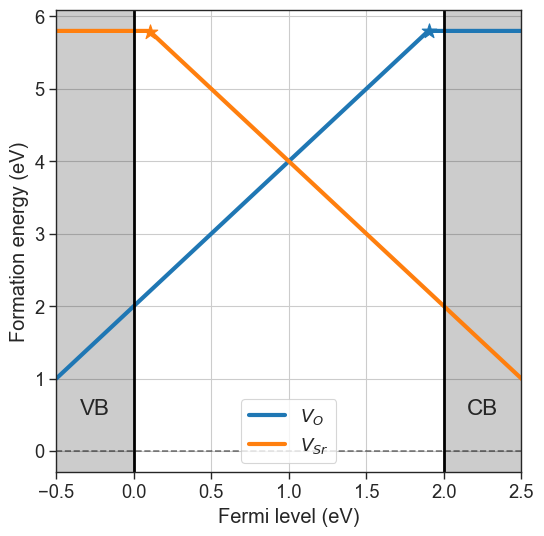

In [7]:
chempots = {'O':-5,'Sr':-2}

da.plot_formation_energies(chempots);